In [6]:
import numpy as np

# Set random seed for consistency
np.random.seed(0)

# Number of training examples
m = 100  

# Generate feature values
x1 = np.random.uniform(0, 50, m)  # First feature
x2 = np.random.uniform(0, 50, m)  # Second feature

# Create feature matrix X (including bias term)
X_train = np.c_[np.ones(m), x1, x2]  # Shape: (m, 3)

# True theta values for generating y
true_theta = np.array([4, 3, 5])  # Bias = 4, x1 coefficient = 3, x2 coefficient = 5

# Generate target values with noise
noise = np.random.normal(0, 5, m)  # Gaussian noise
y_train = X_train @ true_theta + noise  # Shape: (m,)

# Reshape y_train into column vector
y_train = y_train.reshape(-1, 1)

# Print dataset samples
print("First 5 rows of X_train:")
print(X_train[:5])

print("\nFirst 5 values of y_train:")
print(y_train[:5])


First 5 rows of X_train:
[[ 1.         27.4406752  33.89082684]
 [ 1.         35.75946832 13.50039866]
 [ 1.         30.1381688  36.75970111]
 [ 1.         27.24415915 48.10942726]
 [ 1.         21.18273997 12.43765718]]

First 5 values of y_train:
[[261.4093394 ]
 [173.38074071]
 [272.47566868]
 [324.09051351]
 [127.24634353]]


In [8]:
import numpy as np

def gaussian_kernel(x_i, x_q, tau):
    """
    Compute the Gaussian kernel (weight) for a data point.

    Equation:
        w_i = exp( - ||x_i - x_q||^2 / (2 * tau^2) )

    Args:
    - x_i: The feature vector of the i-th data point
    - x_q: The query point for which we are making a prediction
    - tau: The bandwidth parameter that controls the width of the neighborhood

    Returns:
    - weight: The weight for the data point based on its distance to the query point
    """
    return np.exp(-np.sum((x_i - x_q)**2) / (2 * tau**2))

def locally_weighted_regression(X_train, y_train, x_query, tau):
    """
    Perform locally weighted regression to fit a model to the data.

    We solve the weighted normal equation:

        θ = (X^T W X)^(-1) X^T W y

    Where:
    - X = Feature matrix of training examples (including bias term)
    - W = Diagonal matrix of weights for each training example
    - y = Target values
    - θ = Optimal model parameters

    Args:
    - X_train: Feature matrix for training data (shape: [m, n+1])
    - y_train: Target vector for training data (shape: [m, 1])
    - x_query: The query point for which we want to make a prediction
    - tau: The bandwidth parameter

    Returns:
    - theta: The model parameters fitted using weighted least squares
    """
    m = len(X_train)  # Number of training examples
    
    # Compute the weight matrix W where W[i, i] = w_i
    W = np.diag([gaussian_kernel(X_train[i], x_query, tau) for i in range(m)])

    # Compute the weighted least squares solution:
    # θ = (X^T W X)^(-1) X^T W y
    X_transpose = X_train.T
    theta = np.linalg.inv(X_transpose @ W @ X_train) @ X_transpose @ W @ y_train

    return theta


In [10]:
def predict_locally_weighted_regression(X_train, y_train, x_query, tau):
    """
    Predict the target value for a given query point using Locally Weighted Regression.

    Equation:
        y_pred = x_query * θ

    Where:
    - x_query = Feature vector of the query point (1 row, n+1 columns)
    - θ = Model parameters computed from weighted least squares

    Args:
    - X_train: Training feature matrix (m, n+1)
    - y_train: Target values for training data (m, 1)
    - x_query: Query point where we want to make a prediction (1, n+1)
    - tau: Bandwidth parameter (controls how much weighting is applied)

    Returns:
    - y_pred: Predicted value for the query point
    """
    theta = locally_weighted_regression(X_train, y_train, x_query, tau)
    y_pred = x_query @ theta  # Compute y_pred using the computed theta
    return y_pred


In [16]:
# Example usage
x_query = np.array([1, 25, 37])  # Bias term + feature values
tau = 0.5  # Bandwidth parameter

y_pred = predict_locally_weighted_regression(X_train, y_train, x_query, tau)
print(f"Predicted y value for x_query={x_query[1:]}: {y_pred[0]:.4f}")

Predicted y value for x_query=[25 37]: 263.1989


In [21]:
import matplotlib.pyplot as plt

def visualize_lwr_weights(X_train, y_train, x_query, tau_values):
    """
    Visualizes how weights are assigned in Locally Weighted Regression for different tau values.
    
    Args:
    - X_train: Training feature matrix (m, 3) -> includes bias, x1, x2
    - y_train: Target values (m, 1)
    - x_query: Query point (1, 3) -> includes bias, x1, x2
    - tau_values: List of tau values to visualize
    
    Returns:
    - Plots showing how different tau values affect weighting
    """

    # Create subplots: One plot per tau value
    fig, axes = plt.subplots(1, len(tau_values), figsize=(5 * len(tau_values), 5))
    
    # If there's only one tau value, put in array so we can loop
    if len(tau_values) == 1:
        axes = [axes]

    # 1 plot per value of tau
    for ax, tau in zip(axes, tau_values):
        
        # Step 1: Compute distances (ignoring bias term)
        # This calculates the squared Euclidean distance between each training point (x1, x2) 
        # and the query point (x_query[1], x_query[2]) 
        distances = np.sum((X_train[:, 1:] - x_query[1:]) ** 2, axis=1)  # Ignore bias term

        # Step 2: Compute weights using the Gaussian kernel function
        # A smaller distance results in a higher weight
        weights = np.exp(-distances / (2 * tau ** 2))
        
        # Step 3: Create a scatter plot of training data points
        # Color points based on their weight (higher weights -> darker colors)
        scatter = ax.scatter(X_train[:, 1], X_train[:, 2], c=weights, cmap="viridis", s=50)
        
        ax.set_title(f"LWR Weights (tau = {tau})")
        ax.set_xlabel("Feature x1")
        ax.set_ylabel("Feature x2")
        fig.colorbar(scatter, ax=ax, label="Weight")
        
        # Mark the query point
        ax.scatter(x_query[1], x_query[2], color='red', marker='x', s=200, label="Query Point")
        
        ax.legend()
    
    plt.show()


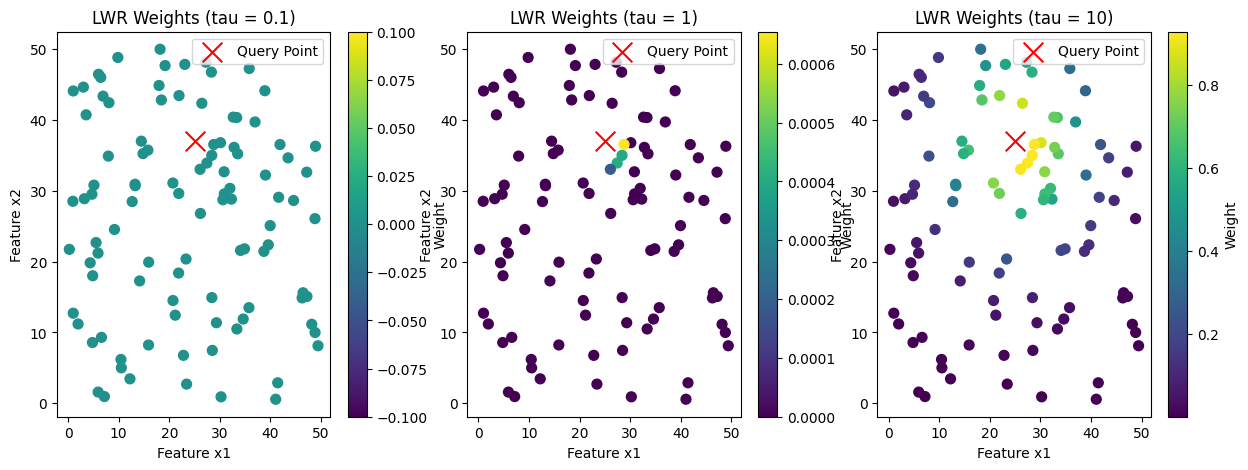

In [22]:
# Example usage:
x_query = np.array([1, 25, 37])  # Bias term + feature values
tau_values = [0.1, 1, 10]  # Different bandwidth values to compare

visualize_lwr_weights(X_train, y_train, x_query, tau_values)